## Tensorflow
## Face Detection

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split

print("Loading data...")
lfw_people = fetch_lfw_people(min_faces_per_person=20, resize=0.5, color=False)

# X is our Tensor of images, y is the label
X = lfw_people.images 
y = lfw_people.target

# TensorFlow expects: (Batch, Height, Width, Channels)
# Since it's grayscale, Channels = 1
X = X.reshape((X.shape[0], X.shape[1], X.shape[2], 1))
X = X / 255.0  # Normalize pixels to [0, 1] range

# Split into Training and Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

# Building the CNN from scratch
model = models.Sequential([
    # Layer 1: Look for 32 different "patterns" (filters)
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(62, 47, 1)),
    layers.MaxPooling2D((2, 2)),
    
    # Layer 2: Look for 64 more complex patterns
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Flattening: Turn the 2D grid into a 1D Vector to "make a decision"
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(len(lfw_people.target_names), activation='softmax')
])

# Compiling and Training
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("Starting training...")
model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

I0000 00:00:1775955095.432013    2153 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775955095.440893    2153 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775955096.464424    2153 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775955099.635655    2153 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

Loading data...
Starting training...
Epoch 1/10


/home/tekraj/kdd-and-data-science/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1775955200.975867    2153 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


71/71 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.1760 - loss: 3.8218 - val_accuracy: 0.1653 - val_loss: 3.7367
Epoch 2/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.1787 - loss: 3.7063 - val_accuracy: 0.1653 - val_loss: 3.7058
Epoch 3/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.1787 - loss: 3.6893 - val_accuracy: 0.1653 - val_loss: 3.7032
Epoch 4/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.1787 - loss: 3.6753 - val_accuracy: 0.1653 - val_loss: 3.6998
Epoch 5/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.1787 - loss: 3.6791 - val_accuracy: 0.1653 - val_loss: 3.6955
Epoch 6/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.1787 - loss: 3.6786 - val_accuracy: 0.1653 - val_loss: 3.6977
Epoch 7/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.1787 - loss: 3.6761 - val_accuracy: 0.1653 - val_loss: 3.7014
Epoch 8/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.1787 - loss: 3.6815 - val_accuracy: 0.1653 - val_loss: 3.

## Model Evaluation

24/24 - 0s - 12ms/step - accuracy: 0.1653 - loss: 3.7018

Test Accuracy: 16.53%
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

Classification Report:
                           precision    recall  f1-score   support

         Alejandro Toledo       0.00      0.00      0.00         8
             Alvaro Uribe       0.00      0.00      0.00        10
          Amelie Mauresmo       0.00      0.00      0.00         2
             Andre Agassi       0.00      0.00      0.00        12
           Angelina Jolie       0.00      0.00      0.00         4
             Ariel Sharon       0.00      0.00      0.00        20
    Arnold Schwarzenegger       0.00      0.00      0.00        13
     Atal Bihari Vajpayee       0.00      0.00      0.00         8
             Bill Clinton       0.00      0.00      0.00         7
             Carlos Menem       0.00      0.00      0.00         6
             Colin Powell       0.00      0.00      0.00        61
            David Beckham       0.00      0.00     

/home/tekraj/kdd-and-data-science/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/tekraj/kdd-and-data-science/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/tekraj/kdd-and-data-science/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

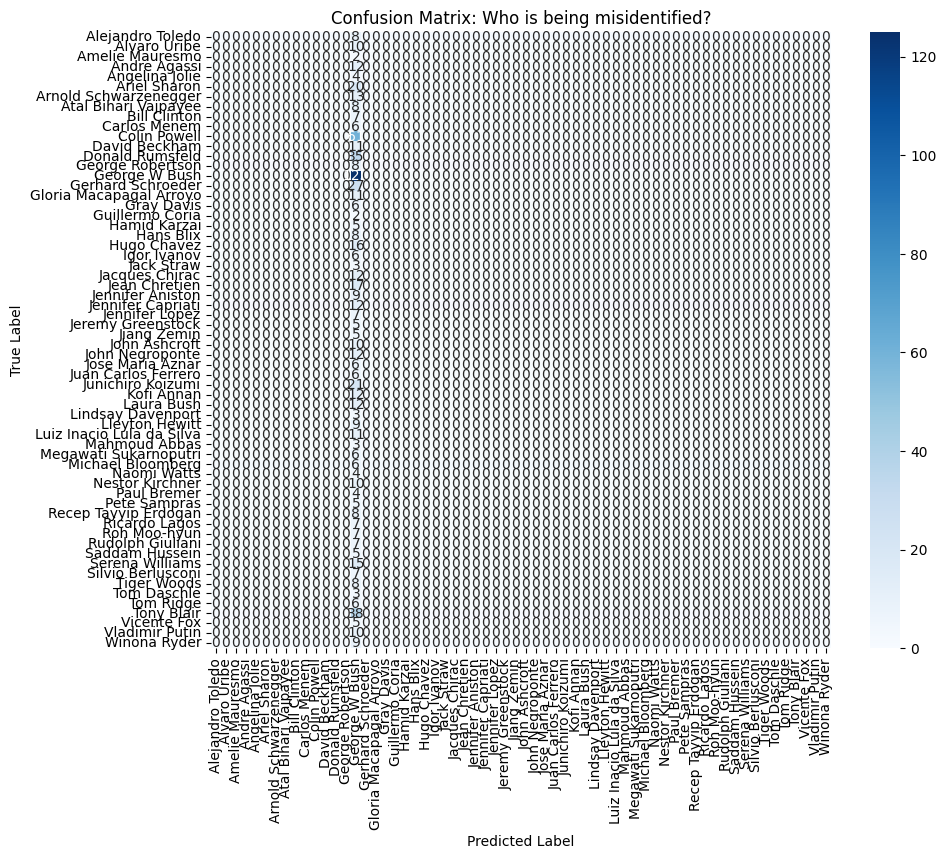

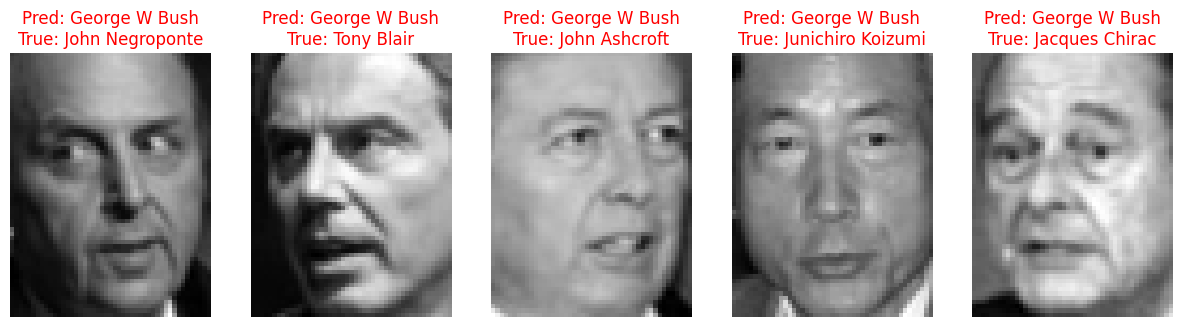

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Evaluate the model on the test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f'\nTest Accuracy: {test_acc*100:.2f}%')

# 2. Get predictions
# model.predict returns probabilities, we use argmax to get the class index
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# 3. Detailed Classification Report
# This shows Precision, Recall, and F1-Score for each person
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=lfw_people.target_names))

# 4. Visualizing the Confusion Matrix
# This helps students see which two people the model "confuses" the most
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=lfw_people.target_names, 
            yticklabels=lfw_people.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Who is being misidentified?')
plt.show()

# 5. Visualizing Specific Predictions
# Let's see the first 5 images from the test set and what the model guessed
plt.figure(figsize=(15, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_test[i].reshape(62, 47), cmap='gray')
    color = 'green' if y_pred[i] == y_test[i] else 'red'
    plt.title(f"Pred: {lfw_people.target_names[y_pred[i]]}\nTrue: {lfw_people.target_names[y_test[i]]}", color=color)
    plt.axis('off')
plt.show()

## Predicting New Student Face

In [3]:
import cv2
import numpy as np

def predict_student_name(image_path, model, target_names):
    # 1. Load the image
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    if img is None:
        return "Image not found"

    # 2. Preprocess to match training data (62x47)
    # This is critical: The Graph expects an exact Input Tensor shape
    img_resized = cv2.resize(img, (47, 62)) 
    img_normalized = img_resized / 255.0
    
    # 3. Reshape for the model: (Batch_Size, Height, Width, Channels)
    # We add the 'Batch' dimension of 1 because the model expects a stack
    input_tensor = img_normalized.reshape((1, 62, 47, 1))

    # 4. Run Inference (The "Flow" through the graph)
    predictions = model.predict(input_tensor)
    
    # 5. Get the result
    predicted_index = np.argmax(predictions[0])
    confidence = np.max(predictions[0])
    
    student_name = target_names[predicted_index]
    
    return student_name, confidence

# --- Usage ---
# name, score = predict_student_name('new_student_face.jpg', model, lfw_people.target_names)
# print(f"Identified as: {name} with {score*100:.2f}% confidence")

ModuleNotFoundError: No module named 'cv2'

# NEPSE Stock Volatility Predictor
# Use LSTM 